<h1 style="text-align: center;font-size: 40px;">Cataract Prediction using DQN</h1>

---

<h3>Dataset Information:</h3>
Ocular Disease Intelligent Recognition (ODIR) is a structured ophthalmic database of 5,000 patients with age, color fundus photographs from left and right eyes and doctors' diagnostic keywords.
We classify images into two categories:
<ul>
  <li><b>Normal</b> – healthy fundus images</li>
  <li><b>Cataract</b> – images diagnosed with cataract</li>
</ul>

In [1]:
# Step 1: Download dataset using KaggleHub
import kagglehub
path = kagglehub.dataset_download('andrewmvd/ocular-disease-recognition-odir5k')
print('Path to dataset files:', path)

Path to dataset files: /kaggle/input/datasets/andrewmvd/ocular-disease-recognition-odir5k


In [2]:
# Step 2: Install required libraries
!pip install tensorflow scikit-learn scipy

In [3]:
# Step 3: Import necessary libraries
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import deque
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam

2026-05-03 10:52:41.356186: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777805561.528343      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777805561.578281      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777805561.971918      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777805561.971957      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777805561.971960      57 computation_placer.cc:177] computation placer alr

In [4]:
# Step 4: Define dataset paths
csv_path  = os.path.join(path, 'full_df.csv')
image_dir = os.path.join(path, 'preprocessed_images')
df = pd.read_csv(csv_path)
df.head(3)

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg


In [5]:
# Step 5: Extract Cataract & Normal image paths
def has_cataract(text):
    return 1 if 'cataract' in str(text).lower() else 0

df['left_cataract']  = df['Left-Diagnostic Keywords'].apply(has_cataract)
df['right_cataract'] = df['Right-Diagnostic Keywords'].apply(has_cataract)

left_cataract   = df.loc[(df.C == 1) & (df.left_cataract  == 1)]['Left-Fundus'].values
right_cataract  = df.loc[(df.C == 1) & (df.right_cataract == 1)]['Right-Fundus'].values
cataract_images = np.concatenate((left_cataract, right_cataract), axis=0)

left_normal  = df.loc[(df.C == 0) & (df['Left-Diagnostic Keywords']  == 'normal fundus')]['Left-Fundus'].sample(250, random_state=42).values
right_normal = df.loc[(df.C == 0) & (df['Right-Diagnostic Keywords'] == 'normal fundus')]['Right-Fundus'].sample(250, random_state=42).values
normal_images = np.concatenate((left_normal, right_normal), axis=0)

print(f'Cataract images : {len(cataract_images)}')
print(f'Normal images   : {len(normal_images)}')

Cataract images : 594
Normal images   : 500


In [6]:
# Step 6: Build DataFrame & validate paths
image_paths = (
    [os.path.join(image_dir, img) for img in cataract_images] +
    [os.path.join(image_dir, img) for img in normal_images]
)
labels = ['CATARACT'] * len(cataract_images) + ['NORMAL'] * len(normal_images)

data_df = pd.DataFrame({'filename': image_paths, 'class': labels})
data_df['label'] = data_df['class'].map({'NORMAL': 0.0, 'CATARACT': 1.0})

data_df = data_df[data_df['filename'].apply(os.path.exists)].reset_index(drop=True)
print(f'Valid images after path check: {len(data_df)}')
print(data_df['class'].value_counts())
data_df.head()

Valid images after path check: 1088
class
CATARACT    588
NORMAL      500
Name: count, dtype: int64


,filename,class,label
0,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
1,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
2,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
3,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0
4,/kaggle/input/datasets/andrewmvd/ocular-diseas...,CATARACT,1.0


<h3>Sample Images from Dataset</h3>

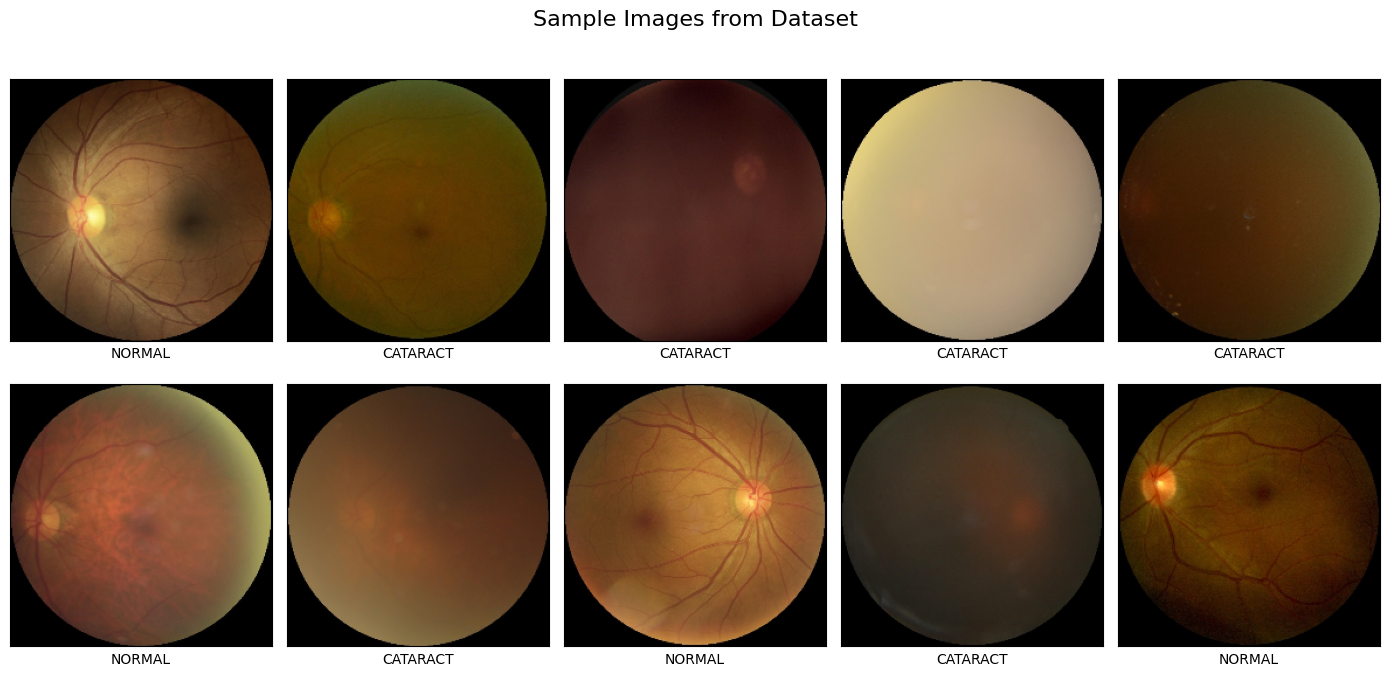

In [7]:
# Step 7: Visualise sample images from dataset
plt.figure(figsize=(14, 7))
sample_rows = data_df.sample(10, random_state=1).reset_index(drop=True)
for i, row in sample_rows.iterrows():
    image = cv2.imread(row['filename'])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.xlabel(row['class'])
    plt.xticks([]); plt.yticks([])
plt.suptitle('Sample Images from Dataset', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
# Step 8: Train / Validation split
train_df, val_df = train_test_split(
    data_df, test_size=0.2, stratify=data_df['label'], random_state=42
)
print(f'Train size: {len(train_df)} | Val size: {len(val_df)}')

Train size: 870 | Val size: 218


In [9]:
# Step 9: Build feature extractor (run ONCE — avoids per-step CNN cost)
IMAGE_SIZE = (224, 224)

def load_image(path):
    img = cv2.imread(path)
    if img is None:
        for ext in ['.jpg', '.jpeg', '.png', '.bmp']:
            alt = os.path.splitext(path)[0] + ext
            img = cv2.imread(alt)
            if img is not None:
                break
    if img is None:
        img = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE)
    return tf.keras.applications.mobilenet_v2.preprocess_input(img.astype('float32'))

base   = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
pool   = GlobalAveragePooling2D()(base.output)
feat_extractor = Model(inputs=base.input, outputs=pool)

print('Pre-extracting train features...')
train_paths_arr  = train_df['filename'].values
train_labels_arr = train_df['label'].values.astype(int)

BATCH = 64
def extract_features(paths):
    feats = []
    for i in range(0, len(paths), BATCH):
        batch = np.array([load_image(p) for p in paths[i:i+BATCH]])
        feats.append(feat_extractor.predict(batch, verbose=0))
    return np.vstack(feats)

train_features = extract_features(train_paths_arr)
print(f'Train features shape: {train_features.shape}')

print('Pre-extracting val features...')
val_paths_arr    = val_df['filename'].values
val_labels_arr   = val_df['label'].values.astype(int)
val_features     = extract_features(val_paths_arr)
print(f'Val features shape  : {val_features.shape}')
print('Feature extraction complete — DQN will now train on 1280-d vectors only.')

I0000 00:00:1777805588.970011      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777805588.976517      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Pre-extracting train features...


I0000 00:00:1777805593.455872     139 service.cc:152] XLA service 0x7fca4800ce40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777805593.455913     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777805593.455916     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777805594.072694     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-03 10:53:22.830068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 10:53:22.975266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777805604.419291     139 device_co

Train features shape: (870, 1280)
Pre-extracting val features...


2026-05-03 10:53:58.321499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-03 10:53:58.458057: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Val features shape  : (218, 1280)
Feature extraction complete — DQN will now train on 1280-d vectors only.


In [10]:
# Step 10: Build lightweight Q-Network (on top of pre-extracted features)
FEAT_DIM = train_features.shape[1]   # 1280 for MobileNetV2

def build_q_network():
    from tensorflow.keras.layers import Dropout
    from tensorflow.keras.regularizers import l2
    inp = Input(shape=(FEAT_DIM,))
    x   = Dense(128, activation='relu', kernel_regularizer=l2(1e-3))(inp)
    x   = Dropout(0.4)(x)
    x   = Dense(64,  activation='relu', kernel_regularizer=l2(1e-3))(x)
    x   = Dropout(0.3)(x)
    out = Dense(2,   activation='linear')(x)   # Q-values for [NORMAL, CATARACT]
    return Model(inputs=inp, outputs=out)

q_network      = build_q_network()
target_network = build_q_network()
target_network.set_weights(q_network.get_weights())
optimizer      = Adam(learning_rate=1e-3)
q_network.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,354 (673.26 KB)

 Trainable params: 172,354 (673.26 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Step 11: DQN Hyperparameters & Replay Buffer
GAMMA         = 0.95
EPSILON       = 1.0
EPSILON_MIN   = 0.05
EPSILON_DECAY = 0.995
BATCH_SIZE    = 64
UPDATE_TARGET = 100
EPISODES      = 10
REPLAY_BUFFER = deque(maxlen=5000)

def store(state, action, reward, next_state, done):
    REPLAY_BUFFER.append((state, action, reward, next_state, done))

def get_action(feat, epsilon):
    if np.random.rand() < epsilon:
        return random.randint(0, 1)
    q_vals = q_network.predict(feat[np.newaxis], verbose=0)[0]
    return int(np.argmax(q_vals))

@tf.function
def train_step(states, targets):
    with tf.GradientTape() as tape:
        q_pred = q_network(states, training=True)
        loss   = tf.reduce_mean(tf.square(targets - q_pred))
    grads = tape.gradient(loss, q_network.trainable_variables)
    optimizer.apply_gradients(zip(grads, q_network.trainable_variables))
    return loss

def replay():
    if len(REPLAY_BUFFER) < BATCH_SIZE:
        return 0.0
    batch       = random.sample(REPLAY_BUFFER, BATCH_SIZE)
    states      = np.array([b[0] for b in batch], dtype=np.float32)
    actions     = np.array([b[1] for b in batch])
    rewards     = np.array([b[2] for b in batch], dtype=np.float32)
    next_states = np.array([b[3] for b in batch], dtype=np.float32)
    dones       = np.array([b[4] for b in batch])

    q_next  = target_network.predict(next_states, verbose=0)
    targets = q_network.predict(states, verbose=0)
    for i in range(BATCH_SIZE):
        targets[i, actions[i]] = rewards[i] if dones[i] else rewards[i] + GAMMA * np.max(q_next[i])
    return float(train_step(states.astype(np.float32), targets.astype(np.float32)))

In [12]:
# Step 12: Train the DQN agent (fast — no CNN per step!)
train_acc_history, val_acc_history   = [], []
train_loss_history, val_loss_history = [], []
step = 0

for episode in range(EPISODES):
    idx_order  = np.random.permutation(len(train_features))
    ep_rewards, ep_losses = [], []

    for idx in idx_order:
        feat   = train_features[idx]
        label  = train_labels_arr[idx]
        action = get_action(feat, EPSILON)
        reward = 1.0 if action == label else -1.0
        store(feat, action, reward, feat, True)
        loss = replay()
        ep_rewards.append(reward)
        ep_losses.append(loss)
        step += 1
        if step % UPDATE_TARGET == 0:
            target_network.set_weights(q_network.get_weights())

    EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)

    # Evaluate on random 20% subset of train — avoids memorisation inflation
    eval_idx  = np.random.choice(len(train_features), size=int(0.2*len(train_features)), replace=False)
    q_train   = q_network(train_features[eval_idx], training=False).numpy()
    tr_preds  = np.argmax(q_train, axis=1)
    tr_acc    = float(np.mean(tr_preds == train_labels_arr[eval_idx]))
    tr_loss   = float(np.mean([l for l in ep_losses if l > 0] or [0]))

    # Batch validation — fast!
    q_vals   = q_network.predict(val_features, verbose=0)
    val_preds = np.argmax(q_vals, axis=1)
    val_acc  = float(np.mean(val_preds == val_labels_arr))
    val_loss = float(np.mean((val_preds - val_labels_arr) ** 2))

    train_acc_history.append(tr_acc)
    val_acc_history.append(val_acc)
    train_loss_history.append(tr_loss)
    val_loss_history.append(val_loss)

    print(f'Episode {episode+1}/{EPISODES} | '
          f'Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f} | '
          f'Loss: {tr_loss:.4f} | Epsilon: {EPSILON:.3f}')

Episode 1/10 | Train Acc: 0.9943 | Val Acc: 0.9541 | Loss: 0.1138 | Epsilon: 0.995
Episode 2/10 | Train Acc: 1.0000 | Val Acc: 0.9725 | Loss: 0.0490 | Epsilon: 0.990
Episode 3/10 | Train Acc: 1.0000 | Val Acc: 0.9633 | Loss: 0.0305 | Epsilon: 0.985
Episode 4/10 | Train Acc: 1.0000 | Val Acc: 0.9587 | Loss: 0.0288 | Epsilon: 0.980
Episode 5/10 | Train Acc: 1.0000 | Val Acc: 0.9495 | Loss: 0.0272 | Epsilon: 0.975
Episode 6/10 | Train Acc: 1.0000 | Val Acc: 0.9495 | Loss: 0.0280 | Epsilon: 0.970
Episode 7/10 | Train Acc: 1.0000 | Val Acc: 0.9541 | Loss: 0.0275 | Epsilon: 0.966
Episode 8/10 | Train Acc: 1.0000 | Val Acc: 0.9541 | Loss: 0.0242 | Epsilon: 0.961
Episode 9/10 | Train Acc: 1.0000 | Val Acc: 0.9495 | Loss: 0.0263 | Epsilon: 0.956
Episode 10/10 | Train Acc: 1.0000 | Val Acc: 0.9450 | Loss: 0.0251 | Epsilon: 0.951


In [13]:
# Step 13: Generate final predictions
q_vals      = q_network.predict(val_features, verbose=0)
y_pred_prob = tf.nn.softmax(q_vals).numpy()[:, 1]   # P(CATARACT)
y_pred      = (y_pred_prob > 0.5).astype(int)
y_true      = val_labels_arr.astype(int)

<h3>Learning Curve</h3>

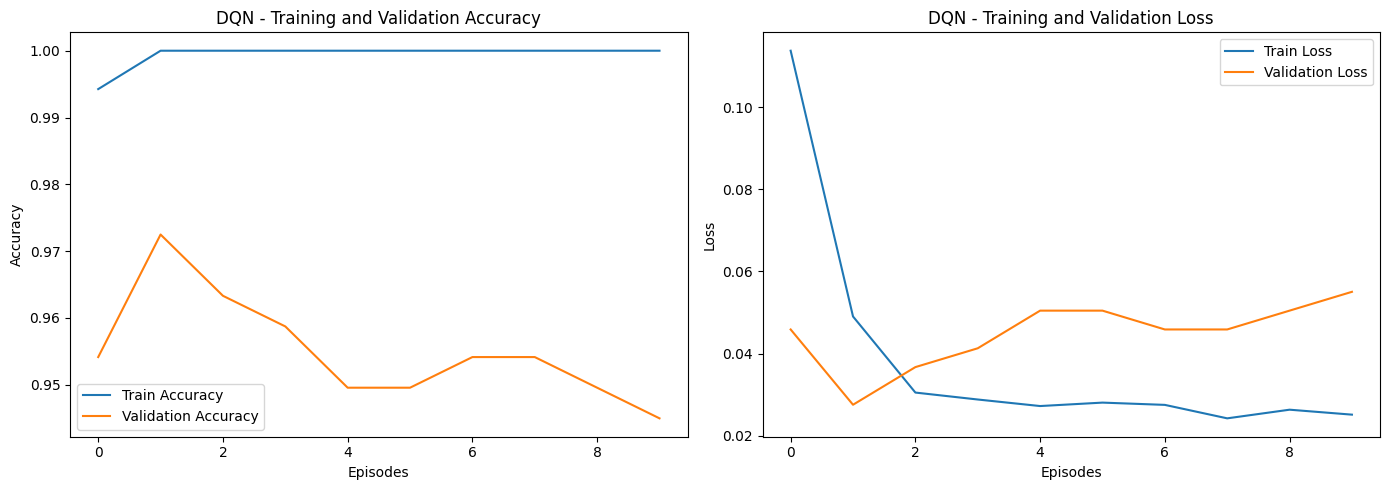

In [14]:
# Plot training history (combined)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc_history,  label='Train Accuracy')
plt.plot(val_acc_history,    label='Validation Accuracy')
plt.title('DQN - Training and Validation Accuracy')
plt.xlabel('Episodes'); plt.ylabel('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history,   label='Validation Loss')
plt.title('DQN - Training and Validation Loss')
plt.xlabel('Episodes'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

### Separate Accuracy & Loss Curves

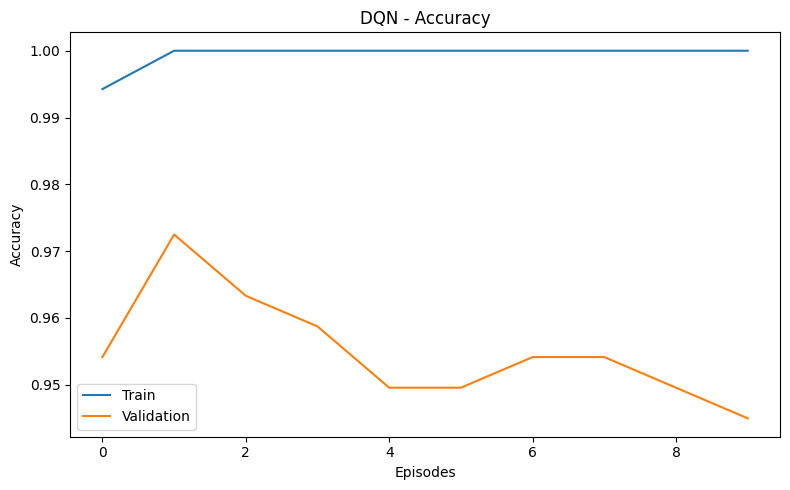

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label='Train')
plt.plot(val_acc_history,   label='Validation')
plt.title('DQN - Accuracy'); plt.xlabel('Episodes'); plt.ylabel('Accuracy')
plt.legend(); plt.tight_layout(); plt.show()

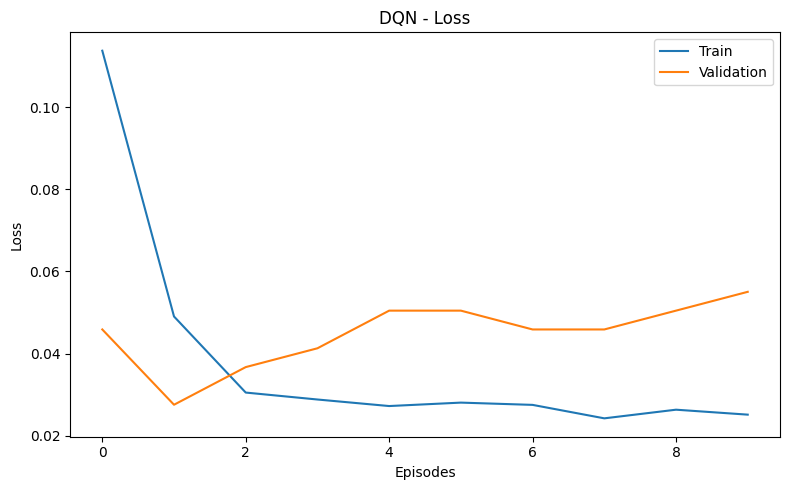

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label='Train')
plt.plot(val_loss_history,   label='Validation')
plt.title('DQN - Loss'); plt.xlabel('Episodes'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout(); plt.show()

<h3>Confusion Matrix</h3>

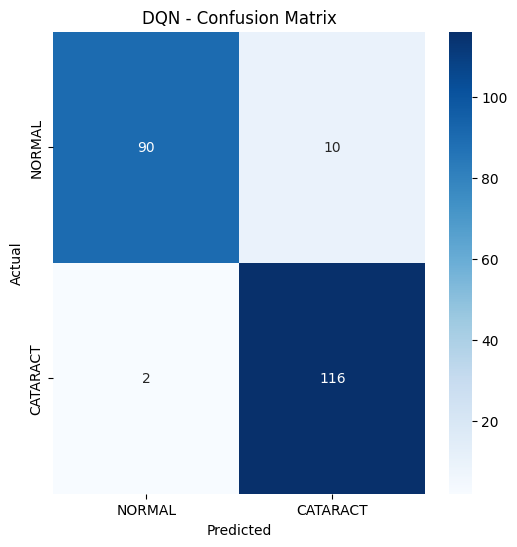

In [17]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL','CATARACT'], yticklabels=['NORMAL','CATARACT'])
plt.title('DQN - Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

### Confusion Matrix — Counts & Normalized

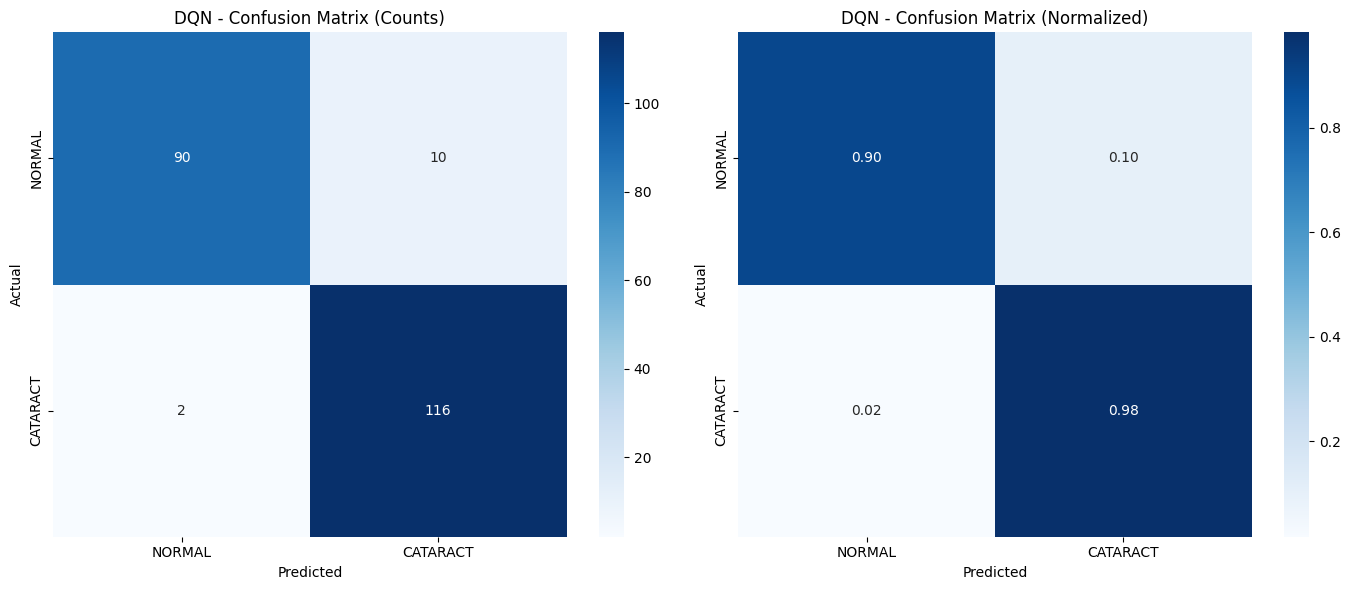

In [26]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues',
            xticklabels=['NORMAL','CATARACT'], yticklabels=['NORMAL','CATARACT'], ax=axes[0])
axes[0].set_title('DQN - Confusion Matrix (Counts)'); axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
sns.heatmap(cm_norm, annot=True, fmt='.2f',  cmap='Blues',
            xticklabels=['NORMAL','CATARACT'], yticklabels=['NORMAL','CATARACT'], ax=axes[1])
axes[1].set_title('DQN - Confusion Matrix (Normalized)'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.show()

In [19]:
print('\nDQN - Classification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'CATARACT']))


DQN - Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.90      0.94       100
    CATARACT       0.92      0.98      0.95       118

    accuracy                           0.94       218
   macro avg       0.95      0.94      0.94       218
weighted avg       0.95      0.94      0.94       218



### ROC Curve

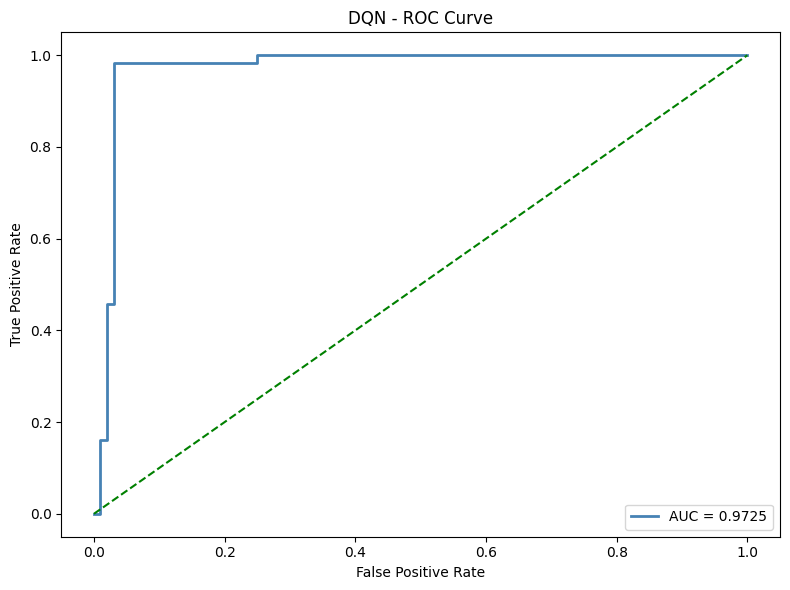

In [20]:
from sklearn.metrics import roc_curve, auc as sk_auc
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc     = sk_auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1], color='green', linestyle='--')
plt.title('DQN - ROC Curve'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

### Error Analysis

<Figure size 800x600 with 0 Axes>

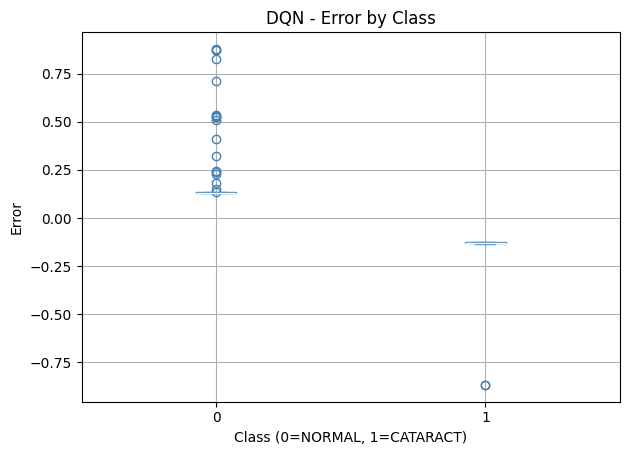

In [21]:
errors   = y_pred_prob - y_true
error_df = pd.DataFrame({'Error': errors, 'Class': y_true})
plt.figure(figsize=(8, 6))
error_df.boxplot(column='Error', by='Class', patch_artist=True,
                 boxprops=dict(facecolor='steelblue', color='steelblue'),
                 medianprops=dict(color='white'), whiskerprops=dict(color='steelblue'),
                 capprops=dict(color='steelblue'),
                 flierprops=dict(markerfacecolor='none', markeredgecolor='steelblue'))
plt.title('DQN - Error by Class'); plt.suptitle('')
plt.xlabel('Class (0=NORMAL, 1=CATARACT)'); plt.ylabel('Error')
plt.tight_layout(); plt.show()

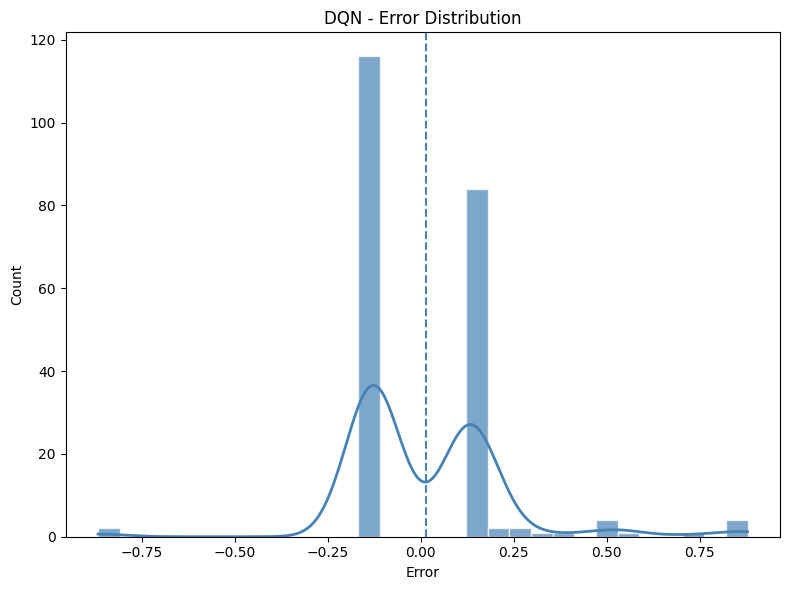

In [22]:
from scipy.stats import gaussian_kde
errors = y_pred_prob - y_true
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
kde_x = np.linspace(errors.min(), errors.max(), 300)
kde_y = gaussian_kde(errors)(kde_x) * len(errors) * (errors.max()-errors.min()) / 30
plt.plot(kde_x, kde_y, color='steelblue', lw=2)
plt.axvline(errors.mean(), color='steelblue', linestyle='--')
plt.title('DQN - Error Distribution'); plt.xlabel('Error'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

### Prediction Probability & Scatter

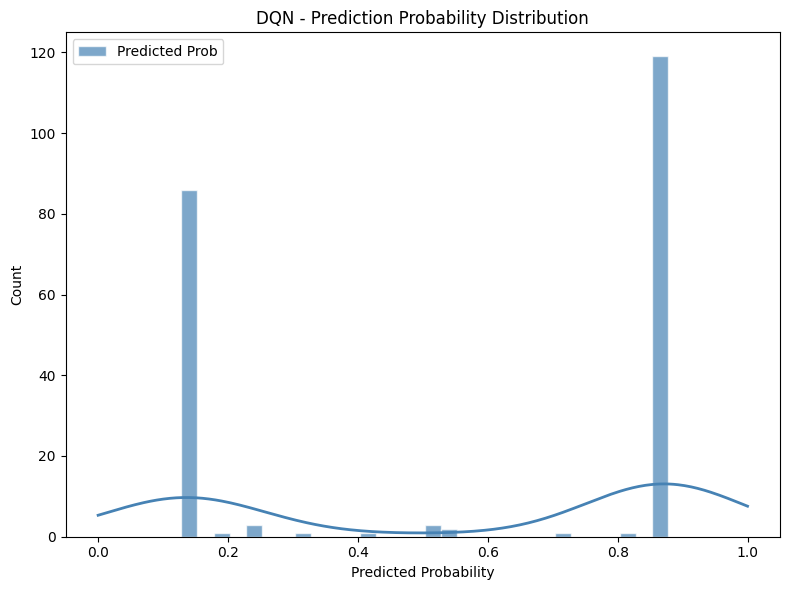

In [23]:
from scipy.stats import gaussian_kde
probs = y_pred_prob
plt.figure(figsize=(8, 6))
plt.hist(probs, bins=30, alpha=0.7, color='steelblue', edgecolor='white', label='Predicted Prob')
kde_x = np.linspace(0, 1, 300)
kde_y = gaussian_kde(probs)(kde_x) * len(probs) * (1/30)
plt.plot(kde_x, kde_y, color='steelblue', lw=2)
plt.title('DQN - Prediction Probability Distribution')
plt.xlabel('Predicted Probability'); plt.ylabel('Count'); plt.legend()
plt.tight_layout(); plt.show()

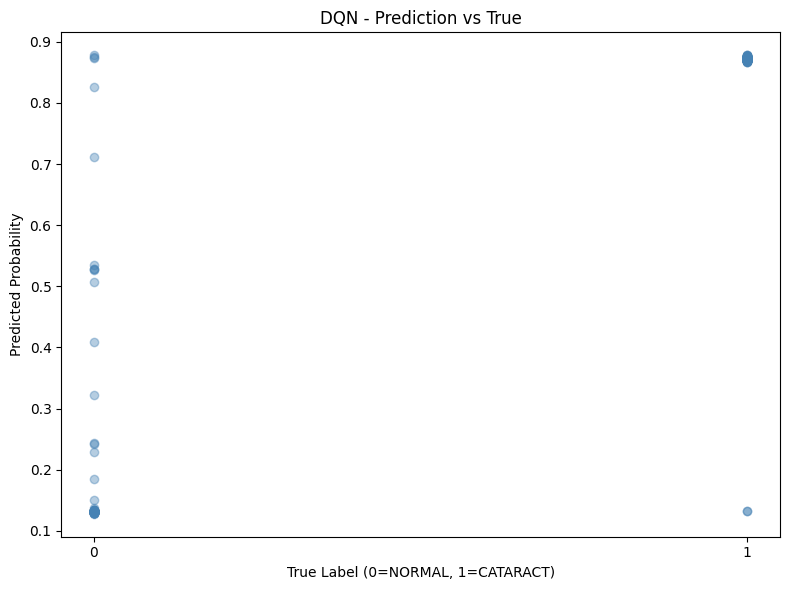

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred_prob, alpha=0.4, color='steelblue')
plt.title('DQN - Prediction vs True')
plt.xlabel('True Label (0=NORMAL, 1=CATARACT)'); plt.ylabel('Predicted Probability')
plt.xticks([0, 1]); plt.tight_layout(); plt.show()

<h3>Prediction: Actual vs Predicted</h3>

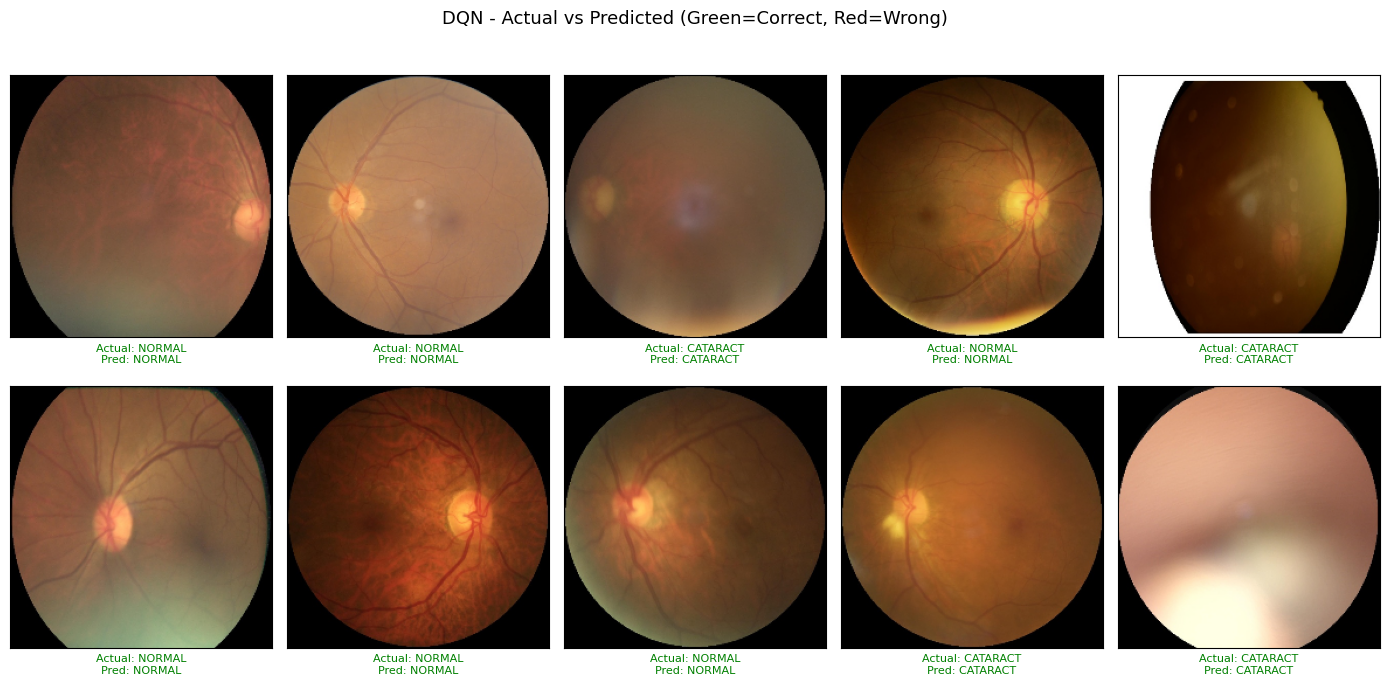

In [25]:
val_paths_list = val_df['filename'].reset_index(drop=True).values
class_map = {0: 'NORMAL', 1: 'CATARACT'}
plt.figure(figsize=(14, 7))
indices = random.sample(range(len(val_paths_list)), 10)
for plot_i, idx in enumerate(indices):
    image = cv2.imread(val_paths_list[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    actual    = class_map[y_true[idx]]
    predicted = class_map[y_pred[idx]]
    color     = 'green' if actual == predicted else 'red'
    plt.subplot(2, 5, plot_i + 1)
    plt.imshow(image)
    plt.xlabel(f'Actual: {actual}\nPred: {predicted}', color=color, fontsize=8)
    plt.xticks([]); plt.yticks([])
plt.suptitle('DQN - Actual vs Predicted (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout(); plt.show()

In [27]:
# Calculate final accuracy percentage
final_accuracy = val_acc * 100

print("-" * 30)
print(f"FINAL MODEL ANALYSIS")
print("-" * 30)
print(f"Overall Accuracy: {final_accuracy:.2f}%")
print(f"Total Val Samples: {len(val_labels_arr)}")
print("-" * 30)

------------------------------
FINAL MODEL ANALYSIS
------------------------------
Overall Accuracy: 94.50%
Total Val Samples: 218
------------------------------
